## **DATA 620 - Project One**
## **Analysis of Centrality Across Twitch Partner Status**
## **Brandon Chanderban**

## **Project Overview**

For this project, I will examine the English-language Twitch social network dataset from the Stanford Network Analysis Project (SNAP). The network represents Twitch users as nodes and mutual relationships between users as edges.

The analysis will calculate degree centrality and eigenvector centrality for each node within the  network and compare these measures across Twitch Partner Status. The primary categorical variable examined will therefore be whether a user possesses Partner status.

## **Import Libraries and Load Datasets**

In [1]:
# Load the relevant required libraries.
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats

# Load the Twitch network edge and target datasets from where it is housed in my
# GitHub repository.
edges_url = "https://raw.githubusercontent.com/bkchanderban/CUNY_SPS/refs/heads/main/DATA620/Week_4_Assignment_and_Project_One/musae_ENGB_edges.csv"

target_url = "https://raw.githubusercontent.com/bkchanderban/CUNY_SPS/refs/heads/main/DATA620/Week_4_Assignment_and_Project_One/musae_ENGB_target.csv"

edges = pd.read_csv(edges_url)
target = pd.read_csv(target_url)

## **Inspect Imported Dataset**

In [2]:
# Display the head (first five rows) of the edge dataset.
edges.head()

,from,to
0,6194,255
1,6194,980
2,6194,2992
3,6194,2507
4,6194,986


In [3]:
# Display the head of the target dataset.
target.head()

,id,days,mature,views,partner,new_id
0,73045350,1459,False,9528,False,2299
1,61573865,1629,True,3615,False,153
2,171688860,411,True,46546,False,397
3,117338954,953,True,5863,False,5623
4,135804217,741,True,5594,False,5875


In [4]:
# Display the dimensions and column names of each dataset.
print("Edges dataset shape:", edges.shape)
print("Edges columns:", edges.columns.tolist())

print("\nTarget dataset shape:", target.shape)
print("Target columns:", target.columns.tolist())

Edges dataset shape: (35324, 2)
Edges columns: ['from', 'to']

Target dataset shape: (7126, 6)
Target columns: ['id', 'days', 'mature', 'views', 'partner', 'new_id']


## **Construct the Twitch Network**

The edge dataset represents relationships between Twitch users, with each user represented as a node within the network. An undirected NetworkX graph will be constructed from the "from" and "to" columns of the edge dataset.

In [5]:
# Construct an undirected graph from the Twitch edge dataset.
G = nx.from_pandas_edgelist(
    edges,
    source="from", target="to",
    )

# Display basic network information.
print(f"There are {G.number_of_nodes()} nodes within the Twitch network.")
print(f"There are {G.number_of_edges()} edges within the Twitch network.")

# Verify that the node IDs in the graph correspond to the new_id column in the target
# dataset.
graph_nodes = set(G.nodes())
target_nodes = set(target["new_id"])

print(f"\nThere are {len(graph_nodes - target_nodes)} nodes in the graph but not in the target dataset.")
print(f"There are {len(target_nodes - graph_nodes)} nodes in the target dataset but not in the graph.")

There are 7126 nodes within the Twitch network.
There are 35324 edges within the Twitch network.

There are 0 nodes in the graph but not in the target dataset.
There are 0 nodes in the target dataset but not in the graph.


## **Assign Twitch Partner Status**

The "partner" column within the target dataset identifies whether each Twitch user possesses Partner status. Using the "new_id" column, Partner status will be assigned as an attribute to each corresponding node within the network.

In [6]:
# Create a dictionary mapping each node ID to its Partner status.
partner_status = target.set_index("new_id")["partner"].to_dict()

# Assign the Partner status as an attribute to each node within the graph.
nx.set_node_attributes(G, partner_status, "partner")

# Display the number of Partner and non-Partner users.
partner_counts = target['partner'].value_counts()

print(f"There are {partner_counts.get(True, 0)} Partner users within the Twitch network.")
print(f"There are {partner_counts.get(False, 0)} non-Partner users within the Twitch network.")

# Verify that the Partner status was assigned to every node.
nodes_with_partner_status = sum(
    "partner" in G.nodes[node] for node in G.nodes()
)

print(f"\nPartner status was assigned to {nodes_with_partner_status} of {G.number_of_nodes()} nodes.")

There are 384 Partner users within the Twitch network.
There are 6742 non-Partner users within the Twitch network.

Partner status was assigned to 7126 of 7126 nodes.


## **Assign Additional Node Attributes**

In addition to Partner status, the target dataset contains information pertaining to the number of views, days, and mature status associated with each Twitch user. These variables will also be assigned as node attributes to preserve additional user information that may support supplementary analyses.

In [7]:
# Create dictionaries mapping each node ID to its additional attributes.
views = target.set_index("new_id")["views"].to_dict()
days = target.set_index("new_id")["days"].to_dict()
mature_status = target.set_index("new_id")["mature"].to_dict()

# Assign the additional attributes to each corresponding node.
nx.set_node_attributes(G, views, "views")
nx.set_node_attributes(G, days, "days")
nx.set_node_attributes(G, mature_status, "mature")

# Verify that all selected attributes were assigned to every node.
selected_attributes = ["partner", "views", "days", "mature"]

nodes_with_all_attributes = sum(
    all(attribute in G.nodes[node] for attribute in selected_attributes)
    for node in G.nodes()
)

print(
    f"{nodes_with_all_attributes} of {G.number_of_nodes()} nodes have all selected attributes."
)

7126 of 7126 nodes have all selected attributes.


## **Calculate Centrality Measures**

Degree centrality and eigenvector centrality will be calculated for each node within the Twitch network. Degree centrality measures a node's number of direct connections relative to the number of possible connections within the network. On the other hand, eigenvector centrality considers not only a node's connections, but also the importance of the nodes to which it is connected.

In [8]:
# Calculate degree centrality for each node.
degree_centrality = nx.degree_centrality(G)

# Assign degree centrality as a node attribute.
nx.set_node_attributes(G, degree_centrality, "degree_centrality")

# Calculate eigenvector centrality for each node.
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Assign eigenvector centrality as a node attribute.
nx.set_node_attributes(G, eigenvector_centrality, "eigenvector_centrality")

# Verify that centrality measures were calculated for each node.
nodes_with_centrality = sum(
    "degree_centrality" in G.nodes[node] and "eigenvector_centrality" in G.nodes[node]
    for node in G.nodes()
)

print(f"{nodes_with_centrality} of {G.number_of_nodes()} nodes have centrality measures.\n")

# Display the attributes and centrality measures for the first five nodes.
for node in list(G.nodes())[:5]:
    print(f"Node {node}: {G.nodes[node]}")

7126 of 7126 nodes have centrality measures.

Node 6194: {'partner': False, 'views': 24940, 'days': 2455, 'mature': True, 'degree_centrality': 0.0008421052631578947, 'eigenvector_centrality': 0.0010355868902520756}
Node 255: {'partner': False, 'views': 118691, 'days': 2659, 'mature': True, 'degree_centrality': 0.0008421052631578947, 'eigenvector_centrality': 0.0016627421519101189}
Node 980: {'partner': True, 'views': 413933, 'days': 2163, 'mature': False, 'degree_centrality': 0.002526315789473684, 'eigenvector_centrality': 0.003863109338500511}
Node 2992: {'partner': False, 'views': 389, 'days': 2014, 'mature': False, 'degree_centrality': 0.0005614035087719298, 'eigenvector_centrality': 0.004121019673678619}
Node 2507: {'partner': False, 'views': 20640, 'days': 2680, 'mature': True, 'degree_centrality': 0.003087719298245614, 'eigenvector_centrality': 0.016286426101453488}


## **Compare Centrality Across Partner Status**

The primary categorical comparison for this analysis concerns Twitch Partner status. To examine whether Partner and non-Partner users differ in their positions within the network, the calculated degree and eigenvector centrality measures will be compared across the two groups.

An analysis dataset will first be constructed containing each node's Partner status, degree centrality, and eigenvector centrality, along with the additional node attributes for subsequent analysis.

In [9]:
# Create a dataframe containing node attributes and centrality measures.
analysis_df = pd.DataFrame.from_dict(
    dict(G.nodes(data=True)),
    orient="index"
)

# Name the index and reset it to create a node ID column.
analysis_df.index.name = "node_id"
analysis_df = analysis_df.reset_index()

# Display the first five rows of the analysis dataset.
analysis_df.head()

,node_id,partner,views,days,mature,degree_centrality,eigenvector_centrality
0,6194,False,24940,2455,True,0.000842,0.001036
1,255,False,118691,2659,True,0.000842,0.001663
2,980,True,413933,2163,False,0.002526,0.003863
3,2992,False,389,2014,False,0.000561,0.004121
4,2507,False,20640,2680,True,0.003088,0.016286


In [10]:
# Display the dimensions and columns of the analysis dataset.
print("Analysis dataset shape:", analysis_df.shape)
print("Analysis columns:", analysis_df.columns.tolist())

Analysis dataset shape: (7126, 7)
Analysis columns: ['node_id', 'partner', 'views', 'days', 'mature', 'degree_centrality', 'eigenvector_centrality']


## **Summarize the Two Categorical Groups**

In [11]:
# Compare descriptive statistics for centrality across Partner status.
centrality_summary = analysis_df.groupby("partner")[
    ["degree_centrality", "eigenvector_centrality"]
].agg(["count", "mean", "median", "std"])

centrality_summary

degree_centrality                                \
                    count      mean    median       std   
partner                                                   
False                6742  0.001085  0.000561  0.001372   
True                  384  0.006777  0.003228  0.010798   

        eigenvector_centrality                                
                         count      mean    median       std  
partner                                                       
False                     6742  0.005092  0.002598  0.006692  
True                       384  0.020514  0.009264  0.030733

## **Examine Centrality Distributions**

The descriptive statistics indicate that Partner users possess higher mean and median degree and eigenvector centrality than non-Partner users. However, the differences between the means and medians, along with the relatively large standard deviations, suggest that the distributions may be skewed. The distributions will therefore be examined visually before conducting inferential statistical comparisons.

## **Examine Degree Centrality**

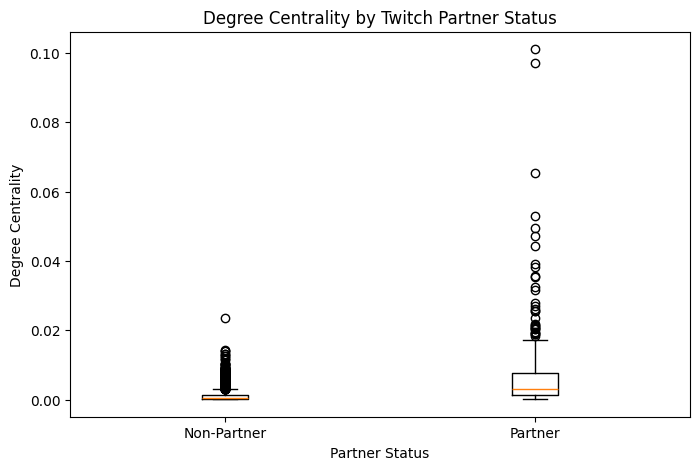

In [12]:
# Create separate datasets for Partner and non-Partner degree centrality
non_partner_degree = analysis_df.loc[
    analysis_df["partner"] == False, "degree_centrality"
]

partner_degree = analysis_df.loc[
    analysis_df["partner"] == True, "degree_centrality"
]

# Create a boxplot comparing degree centrality across Partner status
plt.figure(figsize=(8, 5))
plt.boxplot(
    [non_partner_degree, partner_degree],
    tick_labels=["Non-Partner", "Partner"]
)

plt.title("Degree Centrality by Twitch Partner Status")
plt.xlabel("Partner Status")
plt.ylabel("Degree Centrality")
plt.show()

## **Examine Eigenvector Centrality**

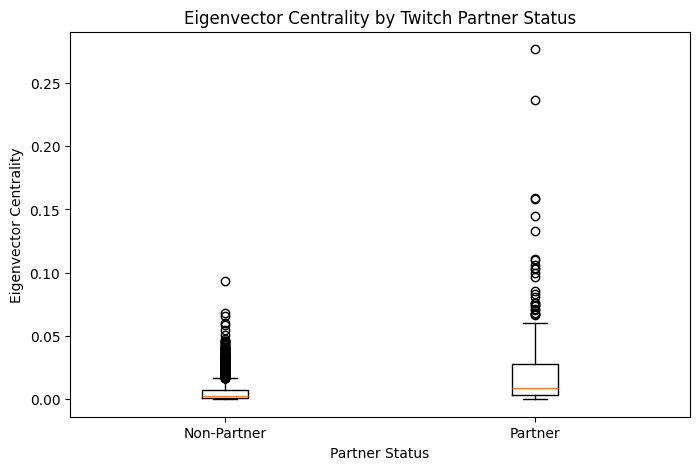

In [13]:
# Create separate datasets for Partner and non-Partner eigenvector centrality
non_partner_eigenvector = analysis_df.loc[
    analysis_df["partner"] == False, "eigenvector_centrality"
]

partner_eigenvector = analysis_df.loc[
    analysis_df["partner"] == True, "eigenvector_centrality"
]

# Create a boxplot comparing eigenvector centrality across Partner status
plt.figure(figsize=(8, 5))
plt.boxplot(
    [non_partner_eigenvector, partner_eigenvector],
    tick_labels=["Non-Partner", "Partner"]
)

plt.title("Eigenvector Centrality by Twitch Partner Status")
plt.xlabel("Partner Status")
plt.ylabel("Eigenvector Centrality")
plt.show()

## **Statistical Comparison of Centrality**

The descriptive statistics and boxplots indicate differences in degree and eigenvector centrality between Partner and non-Partner users. To further assess these differences, Welch's independent-samples t-test will be used to compare the mean centrality measures of the two groups. This version of the t-test is appropriate when the groups differ in size and variability.

In [14]:
# Conduct Welch's t-tests for degree and eigenvector centrality.
degree_ttest = stats.ttest_ind(
    partner_degree,
    non_partner_degree,
    equal_var=False
)

eigenvector_ttest = stats.ttest_ind(
    partner_eigenvector,
    non_partner_eigenvector,
    equal_var=False
)

print("Welch's t-test - Degree Centrality")
print(f"T-statistic is that of {degree_ttest.statistic:.4f}")
print(f"P-value is equal to {degree_ttest.pvalue:.4e}\n")

print("Welch's t-test - Eigenvector Centrality")
print(f"T-statistic is that of {eigenvector_ttest.statistic:.4f}")
print(f"P-value is equal to {eigenvector_ttest.pvalue:.4e}")

Welch's t-test - Degree Centrality
T-statistic is that of 10.3265
P-value is equal to 3.1961e-22

Welch's t-test - Eigenvector Centrality
T-statistic is that of 9.8204
P-value is equal to 1.8419e-20


## **Interpretation**

The Welch's t-tests indicate statistically significant differences in both degree centrality and eigenvector centrality between Partner and non-Partner Twitch users (p < .001 for both measures). In conjunction with the descriptive statistics, these results indicate that Partner users possess higher mean degree centrality and eigenvector centrality than non-Partner users within the examined network. Thus, Partner users tend to possess greater direct connectivity and occupy network positions connected to other relatively influential nodes.

## **Supplementary Network Analysis**

Do Partner users demonstrate a tendency to connect with other Partners, or are their connections more broadly distributed across Partner and non-Partner users?

## **Count Connections by Partner Status**

In [15]:
# Count edges according to the Partner status of connected nodes.
partner_partner = 0
partner_non_partner = 0
non_partner_non_partner = 0

for node1, node2 in G.edges():
    status1 = G.nodes[node1]["partner"]
    status2 = G.nodes[node2]["partner"]

    if status1 and status2:
        partner_partner += 1
    elif status1 != status2:
        partner_non_partner += 1
    else:
        non_partner_non_partner += 1

print(f"There are {partner_partner} Partner to Partner connections.")
print(f"There are {partner_non_partner} Partner to non-Partner connections.")
print(f"There are {non_partner_non_partner} Non-Partner to non-Partner connections.")

print(f"\nThe number of Total connections is that of {G.number_of_edges()}.")

There are 1468 Partner to Partner connections.
There are 15607 Partner to non-Partner connections.
There are 18249 Non-Partner to non-Partner connections.

The number of Total connections is that of 35324.


## **Calculate Connection Proportions**

In [16]:
# Calculate the percentage of all edges represented by each connection type.
total_edges = G.number_of_edges()

print(f"{partner_partner / total_edges * 100:.2f}% of all edges are Partner to Partner connections.")
print(f"{partner_non_partner / total_edges * 100:.2f}% of all edges are Partner to non-Partner connections.")
print(f"{non_partner_non_partner / total_edges * 100:.2f}% of all edges are non-Partner to non-Partner connections.")

4.16% of all edges are Partner to Partner connections.
44.18% of all edges are Partner to non-Partner connections.
51.66% of all edges are non-Partner to non-Partner connections.


## **Measure Assortativity**

In [17]:
# Calculate assortativity according to Twitch Partner status.
partner_assortativity = nx.attribute_assortativity_coefficient(
    G,
    "partner"
)

print(f"The assortativity of the Twitch network according to Partner status is {partner_assortativity:.4f}.")

The assortativity of the Twitch network according to Partner status is -0.1412.


## **Interpretation**

The supplementary analysis indicates that the connections are broadly distributed across Partner and non-Partner users. Of the 35,324 connections, 4.16% occurred between Partners, 44.18% between Partner and non-Partner users, and 51.66% between non-Partners. However, these proportions should be considered alongside the substantial difference in group sizes.

The assortativity coefficient of -0.1412 indicates a weak tendency toward disassortative mixing by Partner status. Thus, users do not appear to strongly favor connections with others possessing the same Partner status, with connections extending across the two groups.

## **Conclusion**

This project examined degree and eigenvector centrality across Partner and non-Partner users within the English-language Twitch network. Partner users possessed higher mean centrality on both measures, with Welch's t-tests indicating statistically significant differences between the groups (p < 0.001). The supplementary analysis further revealed weak disassortative mixing by Partner status (r = -0.1412), suggesting that connections extend broadly across Partner and non-Partner users. Taken together, the findings demonstrate an association between Partner status and greater network centrality, whilst providing little evidence that the network is strongly separated according to Partner status.

## **References**

Rozemberczki, B., Allen, C., & Sarkar, R. (2021). Multi-scale attributed node embedding.
*Journal of Complex Networks, 9*(2), cnab014. https://doi.org/10.1093/comnet/cnab014


Stanford Network Analysis Project. (n.d.). *Twitch social networks*. Stanford University.
https://snap.stanford.edu/data/twitch-social-networks.html